# Fig 3a — Embedding UMAPs

Side-by-side UMAPs of BRCA tumor cell embeddings colored by cell-type label:

- **scVI**
- **Geneformer V1** zero-shot
- **Geneformer V1** after continual training

The notebook:

1. loads only the embedding matrix and label column from each experiment `data.h5ad`;
2. computes a neighbor graph and UMAP in embedding space (`k=25`);
3. saves a shared-legend three-panel figure (PNG at 450 dpi, plus PDF and SVG).

Outputs are written to:

- `./plots/` — `fig3a_umap.{png,pdf,svg}`
- `./fig3_metrics/` — auto-generated figure caption


In [1]:
from pathlib import Path
import importlib

import fig3_umap_utils
importlib.reload(fig3_umap_utils)

from fig3_umap_utils import (
    compute_umap,
    load_embedding_adata,
    plot_umap_panels,
)

PLOTS_DIR = Path("./plots")
METRICS_DIR = Path("./fig3_metrics")
PLOTS_DIR.mkdir(exist_ok=True)
METRICS_DIR.mkdir(exist_ok=True)

OUTPUT_ROOT = Path.home() / "mnt/__output_v8/exp"
N_NEIGHBORS = 25
COLOR_KEY = "label"

PANELS = [
    {
        "title": "scVI",
        "path": OUTPUT_ROOT / "scvi/default/brca_cell_type_scvi_brca_cell_type/data.h5ad",
        "embedding_key": "X_scVI",
    },
    {
        "title": "GF-V1 [Zero-Shot]",
        "path": OUTPUT_ROOT
        / "geneformer/V1-10M-i2048/brca_cell_type_geneformer_V1-10M-i2048_brca_cell_type/data.h5ad",
        "embedding_key": "X_geneformer",
    },
    {
        "title": "GF-V1 [Continual Training]",
        "path": OUTPUT_ROOT
        / "geneformer/V1-10M-i2048/brca_cell_type_continue_geneformer_V1-10M-i2048_continue_brca_cell_type/data.h5ad",
        "embedding_key": "X_geneformer",
    },
]


In [2]:
datasets = []
for cfg in PANELS:
    adata = load_embedding_adata(cfg["path"], cfg["embedding_key"], obs_columns=(COLOR_KEY,))
    print(f"{cfg['title']}: {adata.n_obs:,} cells, {cfg['embedding_key']} {adata.obsm[cfg['embedding_key']].shape}")
    datasets.append({**cfg, "adata": adata})


scVI: 26,697 cells, X_scVI (26697, 100)
GF-V1 [Zero-Shot]: 26,697 cells, X_geneformer (26697, 256)
GF-V1 [Continual Training]: 26,697 cells, X_geneformer (26697, 256)


Computing UMAP: scVI


/home/haitham/scFM_eval/.pixi/envs/geneformer/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Computing UMAP: GF-V1 [Zero-Shot]
Computing UMAP: GF-V1 [Continual Training]


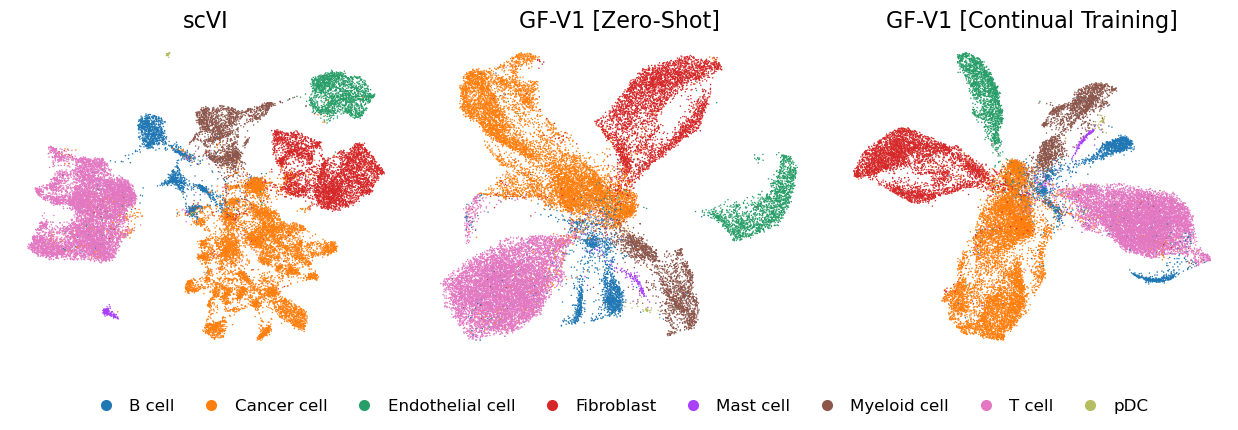

UMAP of pre-treatment BRCA tumor cells (n=26,697 cells) colored by cell-type label (8 categories). Panels compare scVI, GF-V1 [Zero-Shot], GF-V1 [Continual Training]. Neighbor graphs were computed in embedding space (k=25).
Saved PNG: plots/fig3a_umap.png
Saved PDF: plots/fig3a_umap.pdf
Saved SVG: plots/fig3a_umap.svg
Saved caption: fig3_metrics/fig3a_umap_caption.txt


In [3]:
for panel in datasets:
    print(f"Computing UMAP: {panel['title']}")
    compute_umap(panel["adata"], panel["embedding_key"], n_neighbors=N_NEIGHBORS)

result = plot_umap_panels(
    datasets,
    PLOTS_DIR / "fig3a_umap",
    color=COLOR_KEY,
    n_neighbors=N_NEIGHBORS,
    metrics_dir=METRICS_DIR,
    show=True,
)

print(result["caption"])
for fmt, path in result["figures"].items():
    print(f"Saved {fmt.upper()}: {path}")
print(f"Saved caption: {result['caption_path']}")
